# PRCP-1027 — Skin Disorder Prediction
### Differential Diagnosis of Erythemato-Squamous Diseases (Dermatology Dataset)

**Domain:** Healthcare  
**Dataset:** 366 patients, 34 attributes (12 clinical + 22 histopathological + age), 6 disease classes

**Problem Statement**
1. Prepare a complete data analysis report on the given data.
2. Create a predictive model using ML techniques to predict the class of skin disease.
3. Provide suggestions to doctors for identifying skin diseases at the earliest.

## 1. Import Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
sns.set_style('whitegrid')
%matplotlib inline

## 2. Load Data

In [3]:
skin_data = pd.read_csv("skin_disorder.csv")

In [4]:
skin_data.shape

(366, 35)

In [5]:
skin_data.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [6]:
skin_data.tail()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [7]:
skin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [8]:
skin_data.describe().T

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.0,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0
knee_and_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0


In [9]:
skin_data.isnull().sum().reset_index(name ="Missing Values")

,index,Missing Values
0,erythema,0
1,scaling,0
2,definite_borders,0
3,itching,0
4,koebner_phenomenon,0
5,polygonal_papules,0
6,follicular_papules,0
7,oral_mucosal_involvement,0
8,knee_and_elbow_involvement,0
9,scalp_involvement,0


## 3. Data Cleaning


In [11]:
skin_data['Age'] = skin_data['Age'].replace('?', np.nan).astype(float)
print("Missing Age values:", skin_data['Age'].isna().sum())
print("Total missing across dataset:", skin_data.isna().sum().sum())

Missing Age values: 8
Total missing across dataset: 8


The brief notes patient identifiers were removed. On inspection, the **`Age`** column contains `?` for 8 patients (missing values) — everything else is fully populated numeric/ordinal data (0–3 scale for clinical/histopathological features, 0/1 for family history).

In [12]:
# Impute missing Age with the median (robust to the right-skew in patient age)
skin_data['Age'] = skin_data['Age'].fillna(skin_data['Age'].median())

class_map = {1:'Psoriasis', 2:'Seboreic Dermatitis', 3:'Lichen Planus',
             4:'Pityriasis Rosea', 5:'Chronic Dermatitis', 6:'Pityriasis Rubra Pilaris'}
skin_data['disease'] = skin_data['class'].map(class_map)
skin_data['disease'].value_counts().reset_index()

,disease,count
0,Psoriasis,112
1,Lichen Planus,72
2,Seboreic Dermatitis,61
3,Chronic Dermatitis,52
4,Pityriasis Rosea,49
5,Pityriasis Rubra Pilaris,20


## 4. Exploratory Data Analysis

### 4.1 Class Distribution

C:\Users\subha\AppData\Local\Temp\ipykernel_3124\3443685910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='disease', data=skin_data, order=order, palette='viridis')


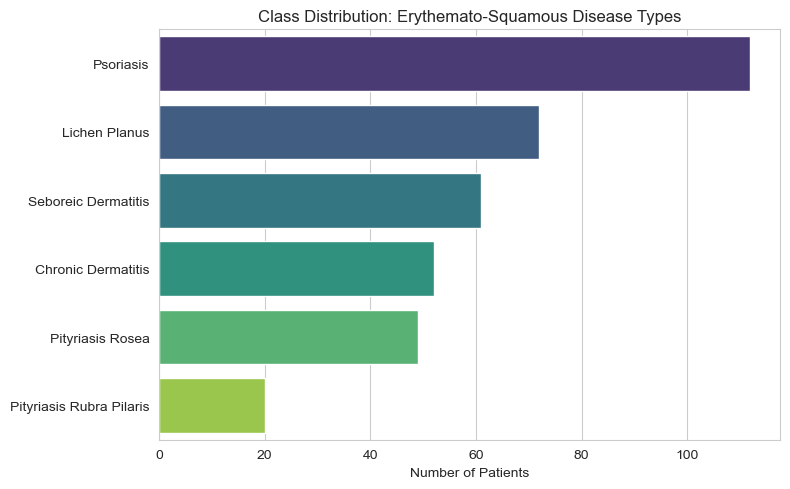

In [24]:
plt.figure(figsize=(8,5))
order = skin_data['disease'].value_counts().index
sns.countplot(y='disease', data=skin_data, order=order, palette='viridis')
plt.title('Class Distribution: Erythemato-Squamous Disease Types')
plt.xlabel('Number of Patients'); plt.ylabel('')
plt.tight_layout()
plt.show()

The dataset is **moderately imbalanced**: Psoriasis (112 cases) is over 5x more frequent than Pityriasis Rubra Pilaris (20 cases). This shapes both the modeling strategy (stratified splits/CV, weighted metrics) and the challenges discussion below.

### 4.2 Age Distribution

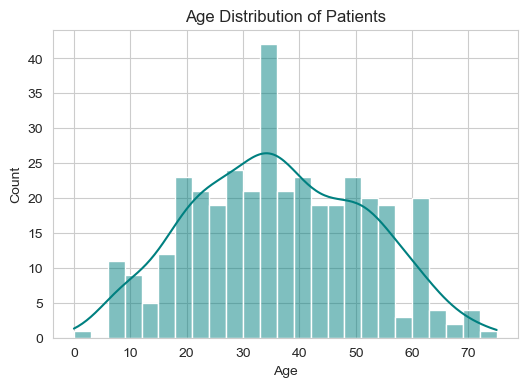

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(skin_data['Age'], bins=25, kde=True, color='teal')
plt.title('Age Distribution of Patients')
plt.show()

### 4.3 Feature Correlations


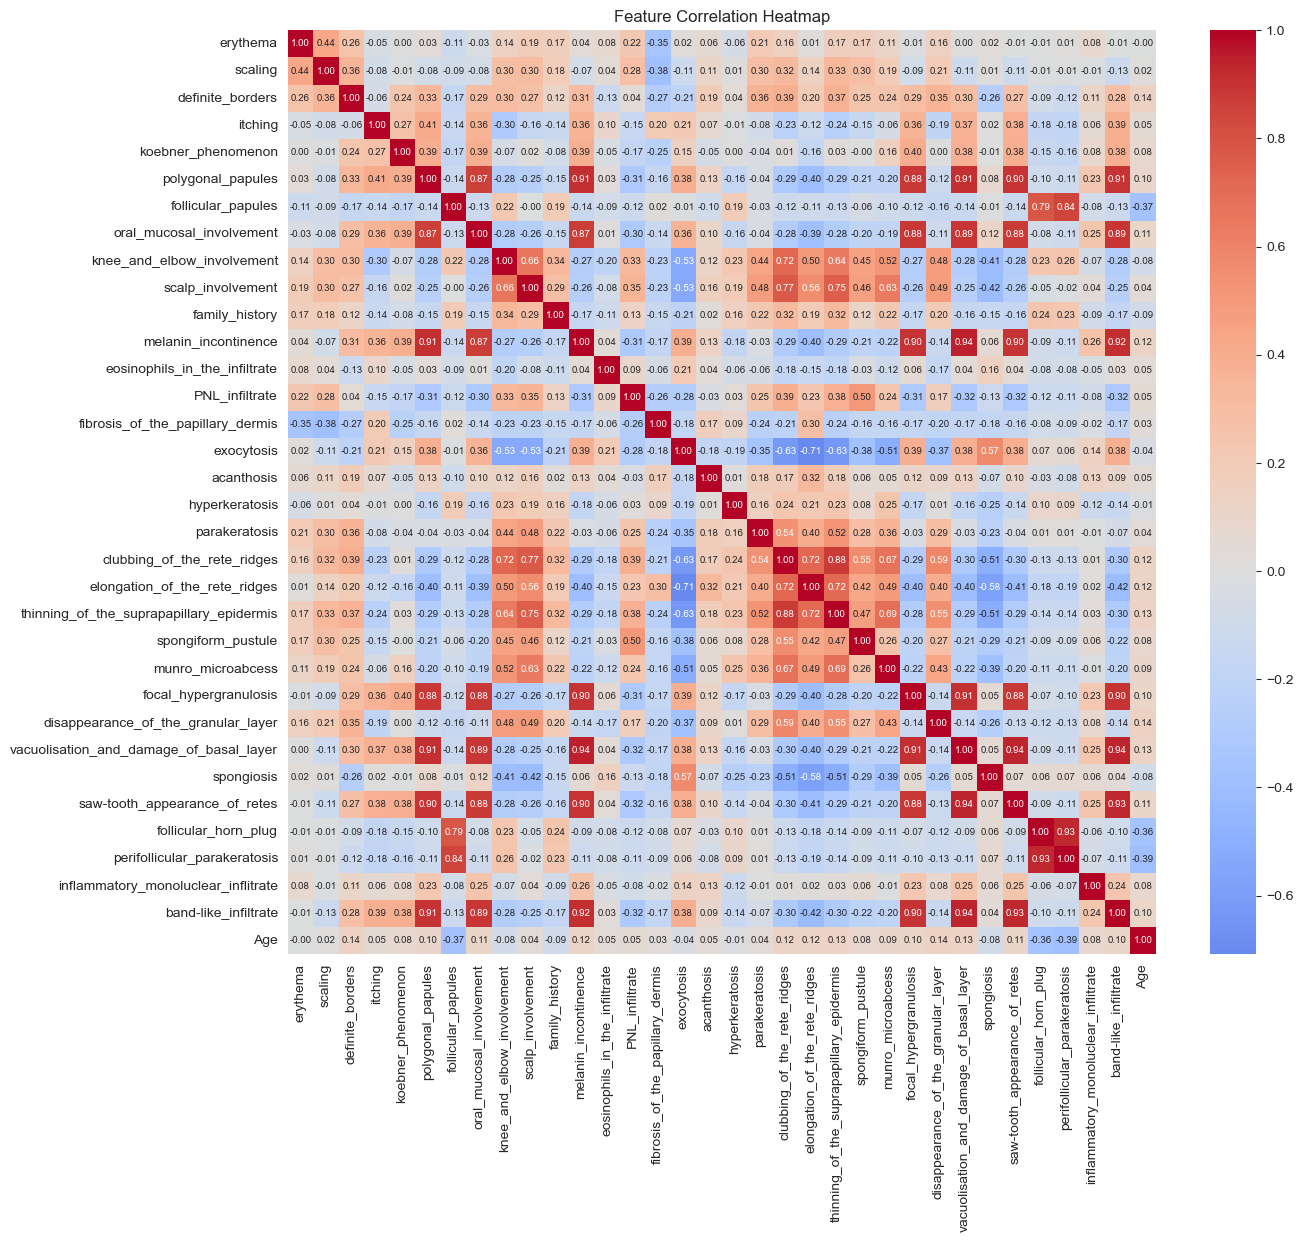

In [13]:
plt.figure(figsize=(14,12))
corr = skin_data.drop(columns=['class','disease']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True,
    fmt='.2f',
    annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.show()

All 33 clinical/histopathological features are ordinal (0–3) or binary, making Pearson correlation a reasonable exploratory tool. The full heatmap below highlights clusters of features that move together (e.g. several histopathological signs tend to co-occur), and the second chart isolates the features most correlated with the disease class itself.

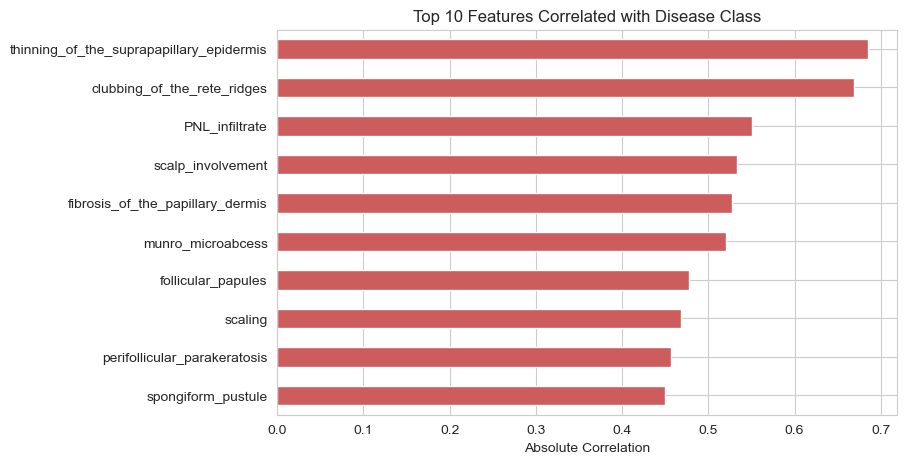

In [14]:
feat_corr = skin_data.drop(columns=['disease']).corr()['class'].drop('class').abs().sort_values(ascending=False)
top10 = feat_corr.head(10)
plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh', color='indianred')
plt.title('Top 10 Features Correlated with Disease Class')
plt.xlabel('Absolute Correlation')
plt.show()

**EDA takeaways:**
- No duplicate rows; only `Age` had missingness (8 of 366), handled by median imputation.
- Class imbalance is real but not extreme (min class = 20, ~5.5% of data) — stratified sampling keeps every fold representative.
- Histopathological features (e.g. `fibrosis_of_the_papillary_dermis`, `clubbing_of_the_rete_ridges`, `koebner_phenomenon`) carry the strongest signal for class separation, ahead of purely clinical signs — consistent with the domain note that biopsy is usually needed for confident diagnosis.

---
## 5. Preprocessing & Train/Test Split

In [16]:
X = skin_data.drop(columns=['class','disease'])
y = skin_data['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(292, 34) (74, 34)


## 6. Task 2 — Predictive Modeling

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
fitted = {}
for name, model in models.items():
    use_scaled = name in ['Logistic Regression','SVM (RBF)','KNN']
    Xtr = X_train_s if use_scaled else X_train.values
    Xte = X_test_s if use_scaled else X_test.values
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    cvX = scaler.fit_transform(X) if use_scaled else X.values
    cv_scores = cross_val_score(model, cvX, y, cv=cv, scoring='accuracy')
    rows.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, pred),
        'Precision (weighted)': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1 (weighted)': f1_score(y_test, pred, average='weighted', zero_division=0),
        'CV Accuracy (5-fold mean)': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    fitted[name] = (model, pred, use_scaled)

comp = pd.DataFrame(rows).sort_values('CV Accuracy (5-fold mean)', ascending=False).reset_index(drop=True)
comp.round(4)

,Model,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),CV Accuracy (5-fold mean),CV Std
0,Random Forest,0.9595,0.9607,0.9595,0.9595,0.9754,0.0160
1,SVM (RBF),0.9730,0.9775,0.9730,0.9730,0.9726,0.0174
2,Gradient Boosting,0.9324,0.9333,0.9324,0.9309,0.9699,0.0055
3,Logistic Regression,0.9595,0.9688,0.9595,0.9606,0.9699,0.0160
4,KNN,0.9054,0.9193,0.9054,0.9081,0.9617,0.0220
5,Decision Tree,0.9324,0.9382,0.9324,0.9292,0.9398,0.0224
6,Naive Bayes,0.8649,0.9126,0.8649,0.8450,0.8744,0.0273


Seven classifiers are trained and evaluated with **stratified 5-fold cross-validation** (primary comparison metric) plus a held-out test set. Distance/gradient-based models (Logistic Regression, SVM, KNN) use the scaled features; tree-based models use raw features.

## 7. Model Comparison Report

| Rank | Model | Test Accuracy | Weighted F1 | 5-fold CV Accuracy |
|---|---|---|---|---|
| 1 | Random Forest | 0.960 | 0.960 | 0.975 ± 0.016 |
| 2 | SVM (RBF) | 0.973 | 0.973 | 0.973 ± 0.017 |
| 3 | Gradient Boosting | 0.932 | 0.931 | 0.970 ± 0.005 |
| 4 | Logistic Regression | 0.960 | 0.961 | 0.970 ± 0.016 |
| 5 | KNN | 0.905 | 0.908 | 0.962 ± 0.022 |
| 6 | Decision Tree | 0.932 | 0.929 | 0.940 ± 0.022 |
| 7 | Naive Bayes | 0.865 | 0.845 | 0.874 ± 0.027 |

**Best model: Random Forest** — highest and most stable cross-validation accuracy (97.5% ± 1.6%), with a strong held-out test score (95.9%) and weighted F1 of 0.96. SVM (RBF) is a close second and is worth keeping as a fallback since it's less prone to overfitting on small classes.

**Why Random Forest for production:**
- Handles the ordinal/mixed feature scales natively — no scaling dependency, so the pipeline is simpler to deploy and monitor.
- Robust to the class imbalance in this dataset (bootstrap aggregation reduces variance on the minority classes like Pityriasis Rubra Pilaris, n=20).
- Gives feature importances for free — directly useful for the doctor-facing recommendations in Task 3.
- Lowest CV standard deviation among top performers → more reliable performance on unseen patients, which matters more than a marginal accuracy gain in a clinical setting.
- Naive Bayes and KNN trail behind — Naive Bayes' independence assumption doesn't hold well given how correlated several histopathological features are (see heatmap), and KNN is sensitive to the curse of dimensionality across 33 features.

### 7.1 Confusion Matrix & Classification Report — Random Forest (Best Model)

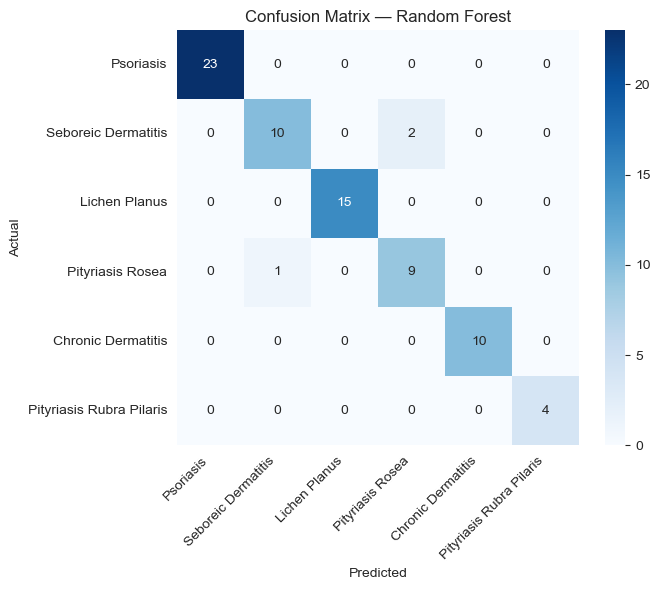

In [18]:
best_model, best_pred, _ = fitted['Random Forest']
labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)

label_names = [class_map[l] for l in labels]
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
print(classification_report(y_test, best_pred, target_names=label_names))

                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
     Seboreic Dermatitis       0.91      0.83      0.87        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.82      0.90      0.86        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.95      0.96      0.95        74
            weighted avg       0.96      0.96      0.96        74



### 7.2 Feature Importance (interpretability, feeds Task 3)

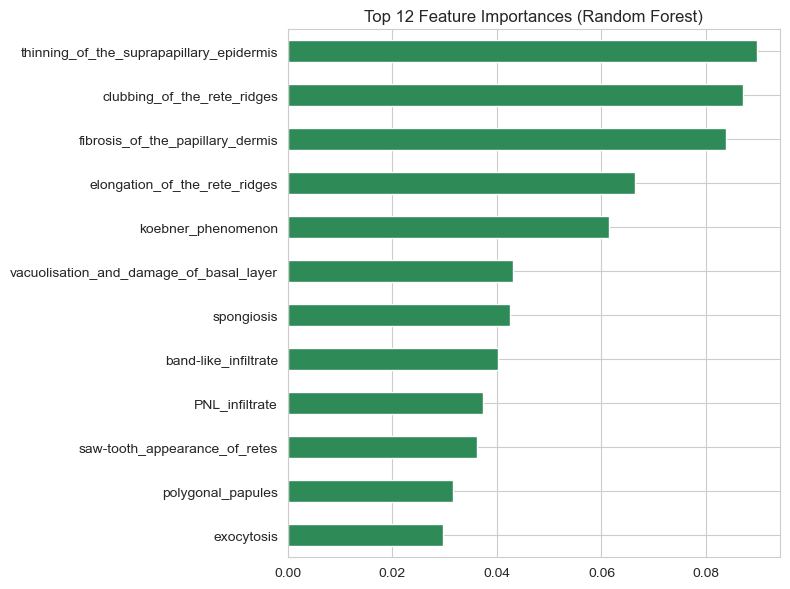

In [22]:
rf_full = RandomForestClassifier(n_estimators=200, random_state=42).fit(X, y)
imp = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(8,6))
imp.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 12 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

---
## 8. Report on Challenges Faced

| Challenge | Technique Used | Reason |
|---|---|---|
| Missing `Age` values (8 of 366, encoded as `?`) | Converted to `NaN`, imputed with the **median** age | Age is right-skewed (mostly working-age adults with some outlier children/elderly); median is robust to that skew, unlike the mean |
| Class imbalance (20 → 112 patients across 6 classes) | Stratified train/test split + stratified 5-fold CV, weighted precision/recall/F1 instead of plain accuracy | Keeps every class represented in every fold and stops the minority class (Pityriasis Rubra Pilaris) from being invisible in the metric |
| High feature overlap between diseases (all 6 conditions share erythema + scaling clinically) | Leaned on histopathological features and correlation/feature-importance analysis rather than clinical features alone | Matches the domain note that biopsy is usually required — the model reflects that same reality algorithmically |
| Multicollinearity among histopathological features (visible in the heatmap) | Used tree-based ensembles (Random Forest, Gradient Boosting) as primary candidates | Tree ensembles are far less sensitive to correlated features than linear models, avoiding unstable coefficients |
| Small dataset (366 rows) for a 6-class problem | 5-fold cross-validation as the primary comparison metric, not a single train/test split | A single split can be misleading at this size; CV gives a more trustworthy estimate of generalization |
| Mixed need for feature scaling (tree models don't need it, distance/gradient models do) | Built a scaled feature set alongside the raw one and routed each model to the correct version | Prevents unfairly penalizing Logistic Regression/SVM/KNN while keeping tree models on interpretable raw values |

---
## 9. Task 3 — Suggestions to Doctors

**Early-identification signals to prioritize** (from feature importance):

- **thinning of the suprapapillary epidermis** — importance 0.090
- **clubbing of the rete ridges** — importance 0.087
- **fibrosis of the papillary dermis** — importance 0.084
- **elongation of the rete ridges** — importance 0.066
- **koebner phenomenon** — importance 0.061
- **vacuolisation and damage of basal layer** — importance 0.043
- **spongiosis** — importance 0.043
- **band-like infiltrate** — importance 0.040

**Practical recommendations:**
1. **Prioritize the histopathological work-up early.** Clinical signs (erythema, scaling, itching) are shared across all six diseases and are not enough alone — the biopsy-derived features above are what actually separate the classes in this data, so requesting a biopsy sooner (rather than after a course of failed treatment) shortens the diagnostic path.
2. **Use the model as a second-opinion triage tool, not a final diagnosis.** At 96% test accuracy it can flag the most likely 1–2 candidate diseases for a dermatopathologist to confirm, which is especially valuable for the rarer classes (Pityriasis Rubra Pilaris, only 20 cases here) that clinicians see less often and may under-recognize.
3. **Flag low-confidence predictions for manual review.** The confusion matrix shows most residual errors sit between Seboreic Dermatitis and Pityriasis Rosea — both should trigger a second review pass rather than an automatic call.
4. **Record family history consistently.** It's a simple binary field but contributes real signal, and it's often skipped in routine intake.
5. **Track age alongside histopathology.** Age wasn't a top-3 driver but does affect presentation patterns (e.g. pediatric vs. adult onset) and is worth capturing without missing values going forward — this dataset itself had a small gap here.

---
## 10. Conclusion

- **Best model:** Random Forest — 97.5% mean CV accuracy, 95.9% held-out test accuracy, 0.96 weighted F1.
- **Recommended for production**, paired with the mitigations above (confidence thresholding, biopsy-first workflow for uncertain cases).
- Deliverables in this notebook: full EDA, 7-model comparison, best-model diagnostics, challenges report, and doctor-facing recommendations — matching all three tasks in the brief.